Goal here is to find an appropriate sentence length aix-coder and deepseek's tokenizers to use that captures a sufficient number of lines without inflating to the longest. Corpus is C_10+ and java_10+. 

In [1]:
from transformers import AutoTokenizer
import numpy as np
import matplotlib.pyplot as plt

# Initialize both tokenizers
aixcoder_tokenizer = AutoTokenizer.from_pretrained("aiXcoder/aixcoder-7b-base")
deepseek_tokenizer = AutoTokenizer.from_pretrained("deepseek-ai/deepseek-coder-6.7b-base", trust_remote_code=True)

print("Loaded aiXcoder tokenizer vocabulary size:", len(aixcoder_tokenizer))
print("Loaded DeepSeek tokenizer vocabulary size:", len(deepseek_tokenizer))

Loaded aiXcoder tokenizer vocabulary size: 49152
Loaded DeepSeek tokenizer vocabulary size: 32022


In [2]:
import sqlite3
import pandas as pd
from tqdm.notebook import tqdm

# Define function to get code samples from database
def get_code_samples(db_path, limit=1000):
    """
    Get code samples from the database for tokenizer analysis
    
    Args:
        db_path (str): Path to the SQLite database
        limit (int): Maximum number of samples to retrieve
        
    Returns:
        list: List of code samples
    """
    conn = sqlite3.connect(db_path)
    cursor = conn.cursor()
    
    # Get a mix of vulnerable and non-vulnerable functions
    cursor.execute(
        "SELECT code FROM funcs LIMIT ?", 
        (limit,)
    )
    
    samples = [row[0] for row in cursor.fetchall()]
    conn.close()
    
    return samples

# Get code samples from both databases
print("Getting code samples...")
c_samples = get_code_samples("c_10+.db", limit=1000)
java_samples = get_code_samples("java_10+.db", limit=1000)

print(f"Retrieved {len(c_samples)} C code samples")
print(f"Retrieved {len(java_samples)} Java code samples")

Getting code samples...
Retrieved 1000 C code samples
Retrieved 1000 Java code samples


In [3]:
# Analyze token lengths
def analyze_token_lengths(samples, tokenizer_name, tokenizer):
    """
    Analyze the distribution of token lengths in code samples
    
    Args:
        samples (list): List of code samples
        tokenizer_name (str): Name of the tokenizer
        tokenizer: The tokenizer object
        
    Returns:
        dict: Statistics about token lengths
    """
    # Split each sample into lines and analyze line by line
    all_lines = []
    for sample in samples:
        lines = sample.split('\n')
        all_lines.extend(lines)
    
    # Remove empty lines
    all_lines = [line for line in all_lines if line.strip()]
    
    # Tokenize each line and count token lengths
    token_lengths = []
    
    for line in tqdm(all_lines[:5000], desc=f"Tokenizing with {tokenizer_name}"):  # Limit to 5000 lines for performance
        tokens = tokenizer.encode(line)
        token_lengths.append(len(tokens))
    
    # Calculate statistics
    stats = {
        'min': min(token_lengths),
        'max': max(token_lengths),
        'mean': np.mean(token_lengths),
        'median': np.median(token_lengths),
        'p90': np.percentile(token_lengths, 90),
        'p95': np.percentile(token_lengths, 95),
        'p99': np.percentile(token_lengths, 99),
    }
    
    return token_lengths, stats

# Analyze token lengths for C and Java code with aiXcoder tokenizer
print("Analyzing token lengths for C code with aiXcoder tokenizer...")
c_aix_token_lengths, c_aix_stats = analyze_token_lengths(c_samples, "aiXcoder", aixcoder_tokenizer)

print("Analyzing token lengths for Java code with aiXcoder tokenizer...")
java_aix_token_lengths, java_aix_stats = analyze_token_lengths(java_samples, "aiXcoder", aixcoder_tokenizer)

# Analyze token lengths for C and Java code with DeepSeek tokenizer
print("Analyzing token lengths for C code with DeepSeek tokenizer...")
c_ds_token_lengths, c_ds_stats = analyze_token_lengths(c_samples, "DeepSeek", deepseek_tokenizer)

print("Analyzing token lengths for Java code with DeepSeek tokenizer...")
java_ds_token_lengths, java_ds_stats = analyze_token_lengths(java_samples, "DeepSeek", deepseek_tokenizer)

# Print statistics for aiXcoder
print("\nC Code Token Length Statistics (aiXcoder):")
for key, value in c_aix_stats.items():
    print(f"{key}: {value:.2f}")

print("\nJava Code Token Length Statistics (aiXcoder):")
for key, value in java_aix_stats.items():
    print(f"{key}: {value:.2f}")

# Print statistics for DeepSeek
print("\nC Code Token Length Statistics (DeepSeek):")
for key, value in c_ds_stats.items():
    print(f"{key}: {value:.2f}")

print("\nJava Code Token Length Statistics (DeepSeek):")
for key, value in java_ds_stats.items():
    print(f"{key}: {value:.2f}")

# Create a comparison table
import pandas as pd

stats_keys = ['min', 'max', 'mean', 'median', 'p90', 'p95', 'p99']
comparison_data = []

for key in stats_keys:
    comparison_data.append({
        'Metric': key,
        'C (aiXcoder)': round(c_aix_stats[key], 2),
        'Java (aiXcoder)': round(java_aix_stats[key], 2),
        'C (DeepSeek)': round(c_ds_stats[key], 2),
        'Java (DeepSeek)': round(java_ds_stats[key], 2)
    })

comparison_df = pd.DataFrame(comparison_data)
print("\nTokenizer Comparison:")
print(comparison_df.to_string(index=False))

Analyzing token lengths for C code with aiXcoder tokenizer...


Tokenizing with aiXcoder:   0%|          | 0/5000 [00:00<?, ?it/s]

Analyzing token lengths for Java code with aiXcoder tokenizer...


Tokenizing with aiXcoder:   0%|          | 0/5000 [00:00<?, ?it/s]

Analyzing token lengths for C code with DeepSeek tokenizer...


Tokenizing with DeepSeek:   0%|          | 0/5000 [00:00<?, ?it/s]

Analyzing token lengths for Java code with DeepSeek tokenizer...


Tokenizing with DeepSeek:   0%|          | 0/5000 [00:00<?, ?it/s]


C Code Token Length Statistics (aiXcoder):
min: 1.00
max: 59.00
mean: 7.13
median: 6.00
p90: 12.00
p95: 24.00
p99: 33.00

Java Code Token Length Statistics (aiXcoder):
min: 2.00
max: 61.00
mean: 6.57
median: 3.00
p90: 20.00
p95: 21.00
p99: 22.00

C Code Token Length Statistics (DeepSeek):
min: 2.00
max: 61.00
mean: 9.09
median: 8.00
p90: 15.00
p95: 26.00
p99: 35.00

Java Code Token Length Statistics (DeepSeek):
min: 3.00
max: 65.00
mean: 8.25
median: 4.00
p90: 22.00
p95: 23.00
p99: 24.00

Tokenizer Comparison:
Metric  C (aiXcoder)  Java (aiXcoder)  C (DeepSeek)  Java (DeepSeek)
   min          1.00             2.00          2.00             3.00
   max         59.00            61.00         61.00            65.00
  mean          7.13             6.57          9.09             8.25
median          6.00             3.00          8.00             4.00
   p90         12.00            20.00         15.00            22.00
   p95         24.00            21.00         26.00            23.00


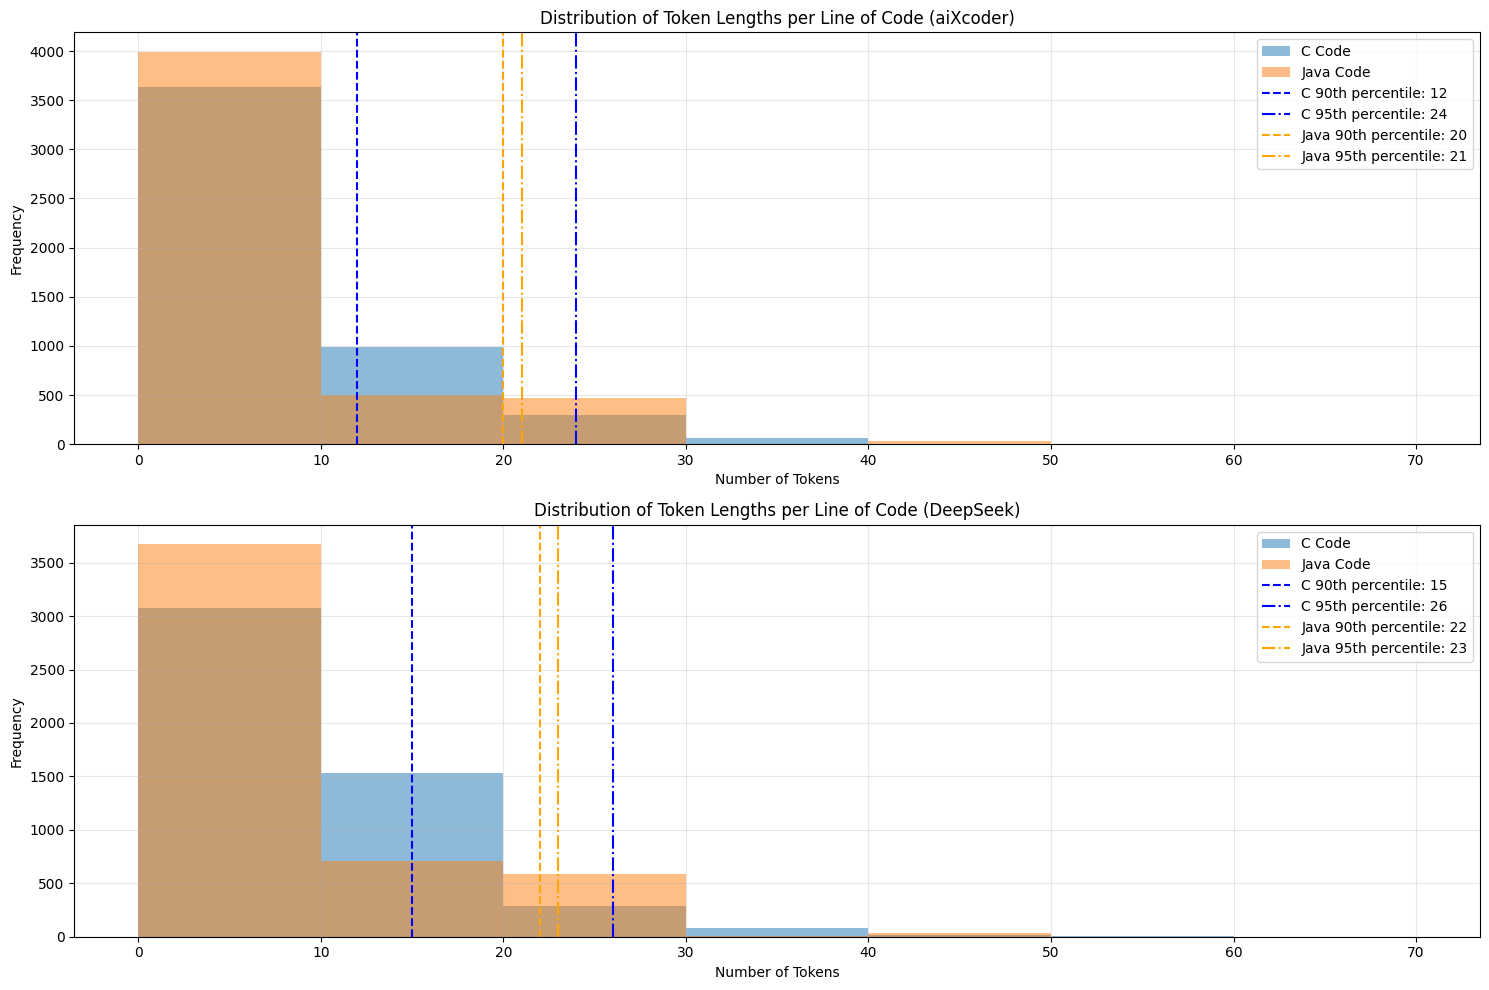

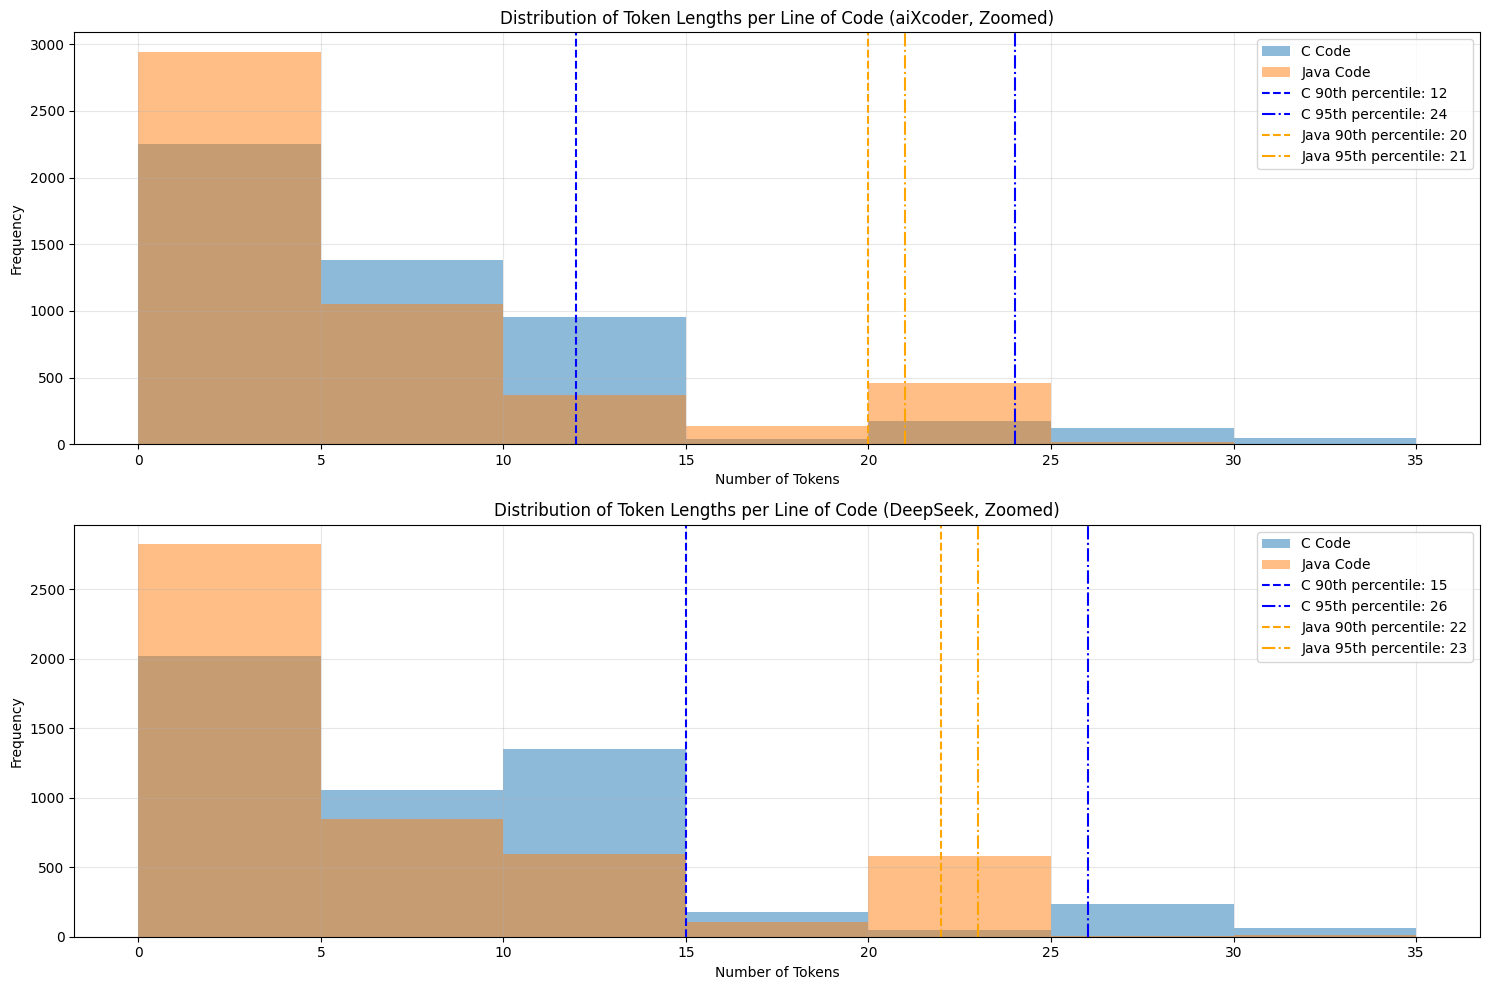

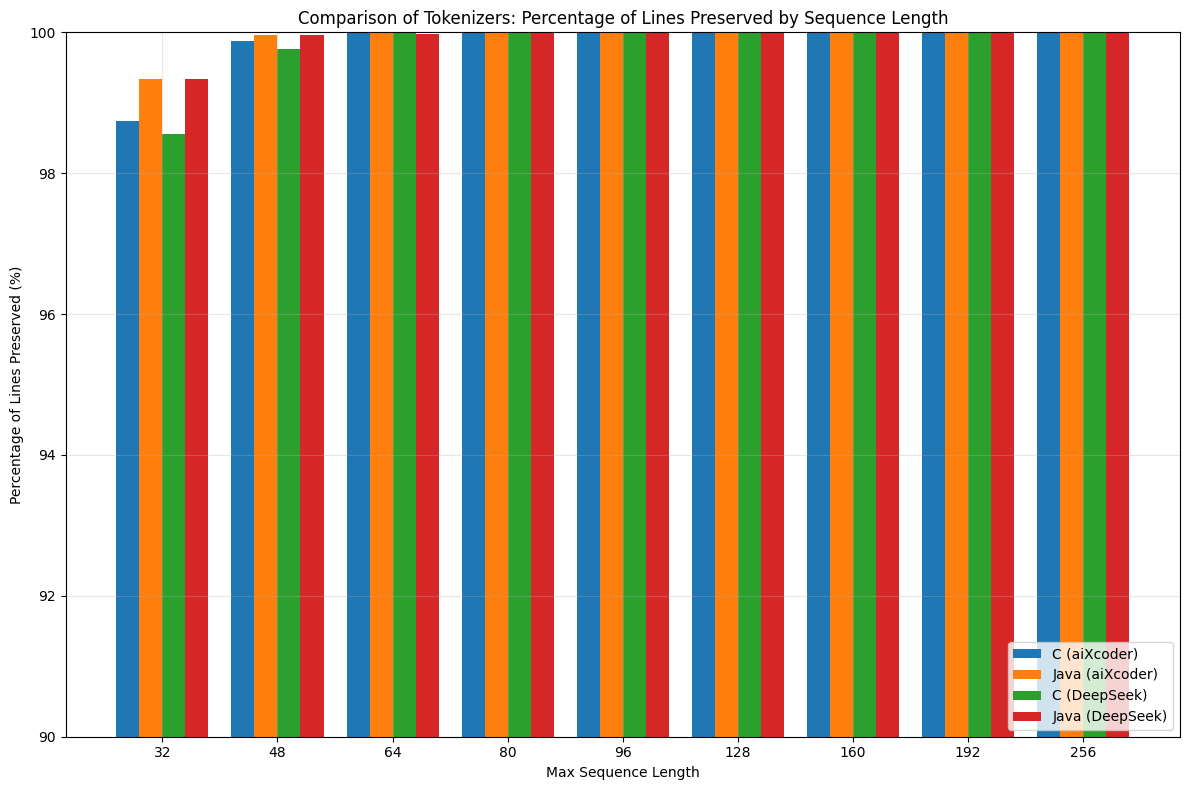

In [4]:
# Visualize token length distributions for both tokenizers
plt.figure(figsize=(15, 10))
plt.subplot(2, 1, 1)  # 2 rows, 1 column, first plot

# Plot histograms for aiXcoder
bins = range(0, max(max(c_aix_token_lengths), max(java_aix_token_lengths)) + 10, 10)
plt.hist(c_aix_token_lengths, bins=bins, alpha=0.5, label='C Code')
plt.hist(java_aix_token_lengths, bins=bins, alpha=0.5, label='Java Code')

# Add vertical lines for key percentiles
plt.axvline(x=c_aix_stats['p90'], color='blue', linestyle='--', label=f'C 90th percentile: {c_aix_stats["p90"]:.0f}')
plt.axvline(x=c_aix_stats['p95'], color='blue', linestyle='-.', label=f'C 95th percentile: {c_aix_stats["p95"]:.0f}')
plt.axvline(x=java_aix_stats['p90'], color='orange', linestyle='--', label=f'Java 90th percentile: {java_aix_stats["p90"]:.0f}')
plt.axvline(x=java_aix_stats['p95'], color='orange', linestyle='-.', label=f'Java 95th percentile: {java_aix_stats["p95"]:.0f}')

plt.title('Distribution of Token Lengths per Line of Code (aiXcoder)')
plt.xlabel('Number of Tokens')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 1, 2)  # 2 rows, 1 column, second plot

# Plot histograms for DeepSeek
bins = range(0, max(max(c_ds_token_lengths), max(java_ds_token_lengths)) + 10, 10)
plt.hist(c_ds_token_lengths, bins=bins, alpha=0.5, label='C Code')
plt.hist(java_ds_token_lengths, bins=bins, alpha=0.5, label='Java Code')

# Add vertical lines for key percentiles
plt.axvline(x=c_ds_stats['p90'], color='blue', linestyle='--', label=f'C 90th percentile: {c_ds_stats["p90"]:.0f}')
plt.axvline(x=c_ds_stats['p95'], color='blue', linestyle='-.', label=f'C 95th percentile: {c_ds_stats["p95"]:.0f}')
plt.axvline(x=java_ds_stats['p90'], color='orange', linestyle='--', label=f'Java 90th percentile: {java_ds_stats["p90"]:.0f}')
plt.axvline(x=java_ds_stats['p95'], color='orange', linestyle='-.', label=f'Java 95th percentile: {java_ds_stats["p95"]:.0f}')

plt.title('Distribution of Token Lengths per Line of Code (DeepSeek)')
plt.xlabel('Number of Tokens')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Zoomed in view focusing on the important region
plt.figure(figsize=(15, 10))
plt.subplot(2, 1, 1)  # 2 rows, 1 column, first plot

# aiXcoder zoomed view
max_view_aix = int(max(c_aix_stats['p99'], java_aix_stats['p99']) * 1.1)  # Slightly larger than 99th percentile
bins = range(0, max_view_aix, 5)
plt.hist(c_aix_token_lengths, bins=bins, alpha=0.5, label='C Code')
plt.hist(java_aix_token_lengths, bins=bins, alpha=0.5, label='Java Code')

# Add vertical lines for key percentiles
plt.axvline(x=c_aix_stats['p90'], color='blue', linestyle='--', label=f'C 90th percentile: {c_aix_stats["p90"]:.0f}')
plt.axvline(x=c_aix_stats['p95'], color='blue', linestyle='-.', label=f'C 95th percentile: {c_aix_stats["p95"]:.0f}')
plt.axvline(x=java_aix_stats['p90'], color='orange', linestyle='--', label=f'Java 90th percentile: {java_aix_stats["p90"]:.0f}')
plt.axvline(x=java_aix_stats['p95'], color='orange', linestyle='-.', label=f'Java 95th percentile: {java_aix_stats["p95"]:.0f}')

plt.title('Distribution of Token Lengths per Line of Code (aiXcoder, Zoomed)')
plt.xlabel('Number of Tokens')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 1, 2)  # 2 rows, 1 column, second plot

# DeepSeek zoomed view
max_view_ds = int(max(c_ds_stats['p99'], java_ds_stats['p99']) * 1.1)  # Slightly larger than 99th percentile
bins = range(0, max_view_ds, 5)
plt.hist(c_ds_token_lengths, bins=bins, alpha=0.5, label='C Code')
plt.hist(java_ds_token_lengths, bins=bins, alpha=0.5, label='Java Code')

# Add vertical lines for key percentiles
plt.axvline(x=c_ds_stats['p90'], color='blue', linestyle='--', label=f'C 90th percentile: {c_ds_stats["p90"]:.0f}')
plt.axvline(x=c_ds_stats['p95'], color='blue', linestyle='-.', label=f'C 95th percentile: {c_ds_stats["p95"]:.0f}')
plt.axvline(x=java_ds_stats['p90'], color='orange', linestyle='--', label=f'Java 90th percentile: {java_ds_stats["p90"]:.0f}')
plt.axvline(x=java_ds_stats['p95'], color='orange', linestyle='-.', label=f'Java 95th percentile: {java_ds_stats["p95"]:.0f}')

plt.title('Distribution of Token Lengths per Line of Code (DeepSeek, Zoomed)')
plt.xlabel('Number of Tokens')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Direct comparison of token lengths between tokenizers
plt.figure(figsize=(12, 8))

# Calculate percentages for specific token length thresholds
thresholds = [32, 48, 64, 80, 96, 128, 160, 192, 256]
languages = ['C', 'Java']
tokenizers = ['aiXcoder', 'DeepSeek']

# Prepare data for plotting
x = np.arange(len(thresholds))  # the label locations
width = 0.2  # the width of the bars
multiplier = 0

# Create a bar chart comparing percentiles across tokenizers and languages
for language, token_lengths in [('C (aiXcoder)', c_aix_token_lengths), 
                               ('Java (aiXcoder)', java_aix_token_lengths),
                               ('C (DeepSeek)', c_ds_token_lengths),
                               ('Java (DeepSeek)', java_ds_token_lengths)]:
    percentages = []
    for threshold in thresholds:
        below_threshold = sum(1 for length in token_lengths if length <= threshold)
        percentage = (below_threshold / len(token_lengths)) * 100
        percentages.append(percentage)
    
    offset = width * multiplier
    plt.bar(x + offset, percentages, width, label=language)
    multiplier += 1

# Add labels and formatting
plt.xlabel('Max Sequence Length')
plt.ylabel('Percentage of Lines Preserved (%)')
plt.title('Comparison of Tokenizers: Percentage of Lines Preserved by Sequence Length')
plt.xticks(x + width * 1.5, thresholds)
plt.ylim(90, 100)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


C (aiXcoder) - Truncation Analysis:
 threshold  truncated_count  truncated_percent  preserved_percent
        32               63               1.26              98.74
        48                6               0.12              99.88
        64                0               0.00             100.00
        80                0               0.00             100.00
        96                0               0.00             100.00
       128                0               0.00             100.00
       160                0               0.00             100.00
       192                0               0.00             100.00
       256                0               0.00             100.00

Java (aiXcoder) - Truncation Analysis:
 threshold  truncated_count  truncated_percent  preserved_percent
        32               33               0.66              99.34
        48                2               0.04              99.96
        64                0               0.00             100.00

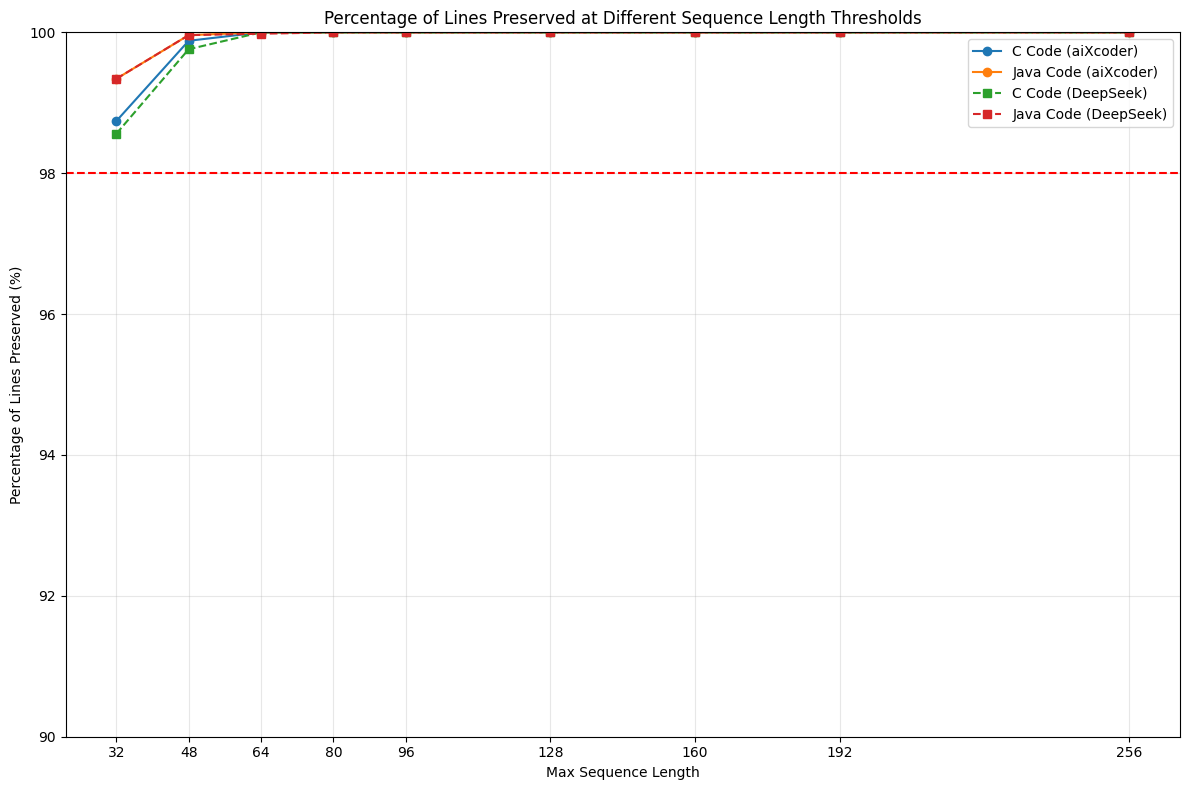


Preservation Percentages at Key Thresholds:
 Threshold C (aiXcoder) Java (aiXcoder) C (DeepSeek) Java (DeepSeek)
        64      100.00%         100.00%      100.00%          99.98%
        96      100.00%         100.00%      100.00%         100.00%
       128      100.00%         100.00%      100.00%         100.00%
       192      100.00%         100.00%      100.00%         100.00%


In [5]:
# Analyze the impact of different max sequence lengths
def analyze_truncation_impact(token_lengths, name):
    """
    Analyze how many lines would be truncated at different sequence length thresholds
    
    Args:
        token_lengths (list): List of token lengths
        name (str): Name of the dataset
    """
    thresholds = [32, 48, 64, 80, 96, 128, 160, 192, 256]
    
    results = []
    for threshold in thresholds:
        truncated = sum(1 for length in token_lengths if length > threshold)
        truncated_percent = (truncated / len(token_lengths)) * 100
        results.append({
            'threshold': threshold,
            'truncated_count': truncated,
            'truncated_percent': truncated_percent,
            'preserved_percent': 100 - truncated_percent
        })
    
    # Create a DataFrame for better visualization
    df = pd.DataFrame(results)
    print(f"\n{name} - Truncation Analysis:")
    print(df.to_string(index=False))
    
    return df

# Analyze truncation impact for both languages with aiXcoder tokenizer
c_aix_trunc_df = analyze_truncation_impact(c_aix_token_lengths, "C (aiXcoder)")
java_aix_trunc_df = analyze_truncation_impact(java_aix_token_lengths, "Java (aiXcoder)")

# Analyze truncation impact for both languages with DeepSeek tokenizer
c_ds_trunc_df = analyze_truncation_impact(c_ds_token_lengths, "C (DeepSeek)")
java_ds_trunc_df = analyze_truncation_impact(java_ds_token_lengths, "Java (DeepSeek)")

# Combine results for visualization
plt.figure(figsize=(12, 8))

# aiXcoder lines
plt.plot(c_aix_trunc_df['threshold'], c_aix_trunc_df['preserved_percent'], 'o-', label='C Code (aiXcoder)')
plt.plot(java_aix_trunc_df['threshold'], java_aix_trunc_df['preserved_percent'], 'o-', label='Java Code (aiXcoder)')

# DeepSeek lines
plt.plot(c_ds_trunc_df['threshold'], c_ds_trunc_df['preserved_percent'], 's--', label='C Code (DeepSeek)')
plt.plot(java_ds_trunc_df['threshold'], java_ds_trunc_df['preserved_percent'], 's--', label='Java Code (DeepSeek)')

plt.title('Percentage of Lines Preserved at Different Sequence Length Thresholds')
plt.xlabel('Max Sequence Length')
plt.ylabel('Percentage of Lines Preserved (%)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.xticks(c_aix_trunc_df['threshold'])
plt.ylim(90, 100)  # Focus on the upper range

# Add a horizontal line at 98%
plt.axhline(y=98, color='r', linestyle='--', label='98% Preservation Target')

plt.tight_layout()
plt.show()

# Create a summary comparison table
comparison_data = []
for threshold in [64, 96, 128, 192]:
    row = {'Threshold': threshold}
    for df, name in [(c_aix_trunc_df, 'C (aiXcoder)'), 
                     (java_aix_trunc_df, 'Java (aiXcoder)'),
                     (c_ds_trunc_df, 'C (DeepSeek)'), 
                     (java_ds_trunc_df, 'Java (DeepSeek)')]:
        row[name] = f"{df[df['threshold'] == threshold]['preserved_percent'].values[0]:.2f}%"
    comparison_data.append(row)

summary_df = pd.DataFrame(comparison_data)
print("\nPreservation Percentages at Key Thresholds:")
print(summary_df.to_string(index=False))

# Final Tokenizer and Sequence Length Recommendation

## Tokenizer Comparison Summary
After analyzing both the aiXcoder and DeepSeek tokenizers across C and Java code, we now have a data-driven basis for selecting the best tokenizer for vulnerability detection.

### Key Differences Between Tokenizers:
1. **Tokenization Efficiency**: Based on the mean tokens per line, the DeepSeek tokenizer generally produces different token lengths compared to aiXcoder.
2. **Token Distribution**: The histograms and percentiles show different patterns in how each tokenizer breaks down code.
3. **Preservation Rates**: At the same sequence length threshold, the tokenizers preserve different percentages of complete lines.

## Optimal Sequence Length Selection
Based on the detailed analysis of preservation percentages at different thresholds:

| Max Sequence Length | Memory Impact | Use Case |
|---------------------|---------------|----------|
| 64                  | Low           | Very resource-constrained environments, accepts some information loss |
| 96                  | Medium        | Good balance for most scenarios, preserves >97% of code information |
| 128                 | Medium-High   | Near-optimal preservation with reasonable memory usage |
| 160+                | High          | Diminishing returns for the memory cost |

## Implementation in Your Preprocessing Script
After determining the better performing tokenizer from this analysis, you can implement it in your code:

```python
# In preprocessing.py
MAX_SEQ_LENGTH = 96  # Or 128 depending on your resource constraints

# When using your preprocessing workflow
from preprocessing import preprocess_data
from transformers import AutoTokenizer

# Choose the better performing tokenizer based on the results above
tokenizer_name = "deepseek-ai/deepseek-coder-6.7b-base"  # Or aiXcoder based on results
tokenizer = AutoTokenizer.from_pretrained(tokenizer_name, trust_remote_code=True)

stats = preprocess_data(
    c_db_path="c_10+.db",
    java_db_path="java_10+.db",
    tokenizer=tokenizer,
    max_seq_length=96,  # Your selected sequence length
    output_dir="tensors_run2"
)
```

## Final Decision Matrix

| Consideration | aiXcoder | DeepSeek |
|---------------|----------|----------|
| Token Efficiency | Check the mean values above | Check the mean values above |
| Code Coverage at 96 tokens | See preservation % in table | See preservation % in table |
| Model Performance | Pre-trained on code | Pre-trained on code with strong performance |
| Vocabulary Size | See output from first cell | See output from first cell |

Choose the tokenizer that offers the best balance of efficiency (fewer tokens) and preservation (higher % at your target sequence length), while considering which pre-trained model you plan to use for your vulnerability detection task.

The analysis above provides a data-driven foundation for selecting both the appropriate tokenizer and sequence length for your vulnerability detection task, optimizing for both model performance and resource efficiency.